<a href="https://colab.research.google.com/github/hawa1983/MG-628/blob/main/Midterm_Regression_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Question 1A: Deal Size and Sales Cycle Trends

### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load the sales performance dataset and group the data by month

In [4]:

sales_df = pd.read_csv('business_sales_performance.csv')

# Preview dataset
sales_df.head()

,Deal_ID,Month,Region,Sales_Rep_ID,Deal_Size_USD,Sales_Cycle_Days,Monthly_Revenue_USD,Deal_Status
0,D-0001,1,West,REP-029,33854.81,46,34297.88,Won
1,D-0002,2,Central,REP-012,38628.50,55,35775.28,Won
2,D-0003,3,Central,REP-007,41541.02,40,43413.59,Won
3,D-0004,4,West,REP-029,26212.43,55,28067.30,Pending
4,D-0005,5,East,REP-011,30907.62,61,28738.42,Lost


### 2. Group Data by Month

In [15]:
monthly_stats = sales_df.groupby('Month').agg({
    'Deal_Size_USD': ['mean','median','std'],
    'Sales_Cycle_Days': ['mean','median','std']
}).reset_index()

monthly_stats

Month Deal_Size_USD                         Sales_Cycle_Days         \
                  mean     median          std             mean median   
0      1    38026.7636  37544.285  4605.335077            45.34   45.0   
1      2    37687.6206  38234.530  4887.820481            44.36   43.0   
2      3    37124.3256  37764.075  4254.276503            43.66   44.0   
3      4    37218.4746  37894.920  5348.472554            47.86   48.0   
4      5    35861.1158  35835.910  4658.321443            48.06   48.0   
5      6    36298.0538  36139.610  4450.532079            47.46   45.5   
6      7    37003.7090  37802.050  4723.241849            50.52   49.0   
7      8    34821.4040  34854.870  3972.269541            50.64   51.5   
8      9    35991.7680  36521.405  4006.273363            49.84   50.0   
9     10    34825.9896  35236.800  4672.314232            50.36   49.5   
10    11    34628.3982  34045.990  5258.896731            50.44   51.0   
11    12    34683.0312  34639.575  5404.933394            52.44   54.0   
12    13    32800.6996  32530.560  5217.312049            52.74   52.0   
13    14    32924.4004  33104.820  5182.082408            53.94   53.5   
14    15    32876.3770  33493.835  5051.955748            57.86   56.5   
15    16    32015.4978  31641.100  5558.337450            54.46   54.5   
16    17    31549.9096  32132.605  4481.490738            55.88   57.0   
17    18    32508.4056  32456.855  5134.310739            58.08   57.5   
18    19    31210.4926  31057.200  4875.856109            59.48   60.0   
19    20    28612.1666  27653.590  4870.947990            60.98   62.0   
20    21    31856.3216  31735.590  5145.180628            58.90   60.0   
21    22    30483.8518  30900.945  5226.775692            59.60   60.0   
22    23    28758.5224  27901.905  5237.298287            61.38   61.0   
23    24    29788.6270  29901.060  4840.516929            61.80   62.0   

              
         std  
0   8.721566  
1   7.718940  
2   7.646821  
3   7.876625  
4   7.072251  
5   8.376863  
6   8.194672  
7   9.635733  
8   7.581826  
9   6.090340  
10  8.418056  
11  7.910623  
12  8.451084  
13  8.862694  
14  6.527837  
15  9.089599  
16  8.006732  
17  8.639822  
18  7.772899  
19  7.825886  
20  8.381832  
21  7.801099  
22  7.024418  
23  7.858441

### Flatten Column Names (easier to use)

In [16]:
monthly_stats.columns = [
    'Month',
    'Deal_Size_Mean',
    'Deal_Size_Median',
    'Deal_Size_STD',
    'Sales_Cycle_Mean',
    'Sales_Cycle_Median',
    'Sales_Cycle_STD'
]

monthly_stats

,Month,Deal_Size_Mean,Deal_Size_Median,Deal_Size_STD,Sales_Cycle_Mean,Sales_Cycle_Median,Sales_Cycle_STD
0,1,38026.7636,37544.285,4605.335077,45.34,45.0,8.721566
1,2,37687.6206,38234.530,4887.820481,44.36,43.0,7.718940
2,3,37124.3256,37764.075,4254.276503,43.66,44.0,7.646821
3,4,37218.4746,37894.920,5348.472554,47.86,48.0,7.876625
4,5,35861.1158,35835.910,4658.321443,48.06,48.0,7.072251
5,6,36298.0538,36139.610,4450.532079,47.46,45.5,8.376863
6,7,37003.7090,37802.050,4723.241849,50.52,49.0,8.194672
7,8,34821.4040,34854.870,3972.269541,50.64,51.5,9.635733
8,9,35991.7680,36521.405,4006.273363,49.84,50.0,7.581826
9,10,34825.9896,35236.800,4672.314232,50.36,49.5,6.090340


### 3. Create line charts showing the month-over-month trend for both variables

#### Plot Trend for Deal Size

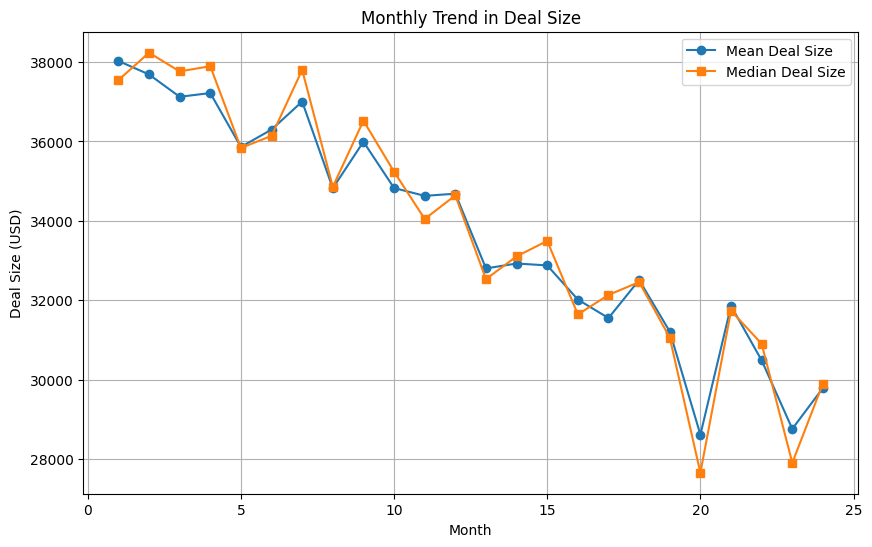

In [17]:
plt.figure(figsize=(10,6))

plt.plot(monthly_stats['Month'], monthly_stats['Deal_Size_Mean'], marker='o', label='Mean Deal Size')
plt.plot(monthly_stats['Month'], monthly_stats['Deal_Size_Median'], marker='s', label='Median Deal Size')

plt.title('Monthly Trend in Deal Size')
plt.xlabel('Month')
plt.ylabel('Deal Size (USD)')
plt.legend()
plt.grid(True)

plt.show()

#### Plot Trend for Sales Cycle

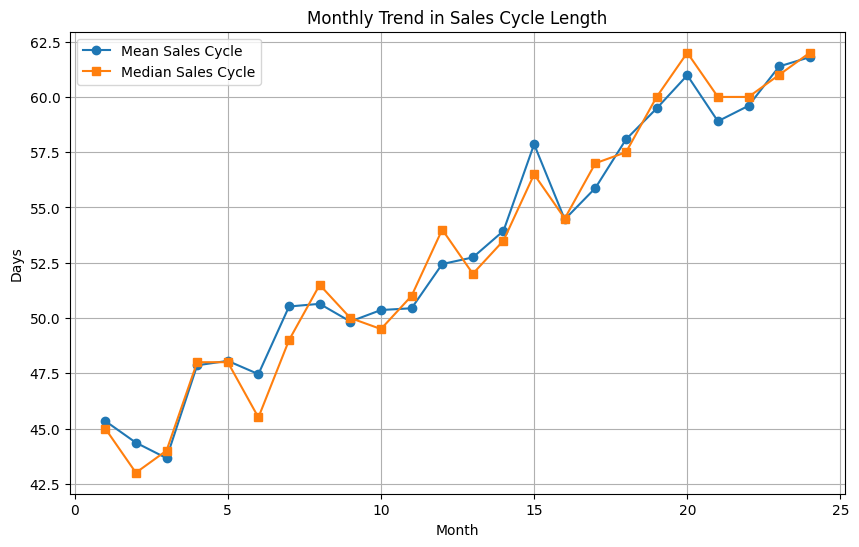

In [18]:
plt.figure(figsize=(10,6))

plt.plot(monthly_stats['Month'], monthly_stats['Sales_Cycle_Mean'], marker='o', label='Mean Sales Cycle')
plt.plot(monthly_stats['Month'], monthly_stats['Sales_Cycle_Median'], marker='s', label='Median Sales Cycle')

plt.title('Monthly Trend in Sales Cycle Length')
plt.xlabel('Month')
plt.ylabel('Days')
plt.legend()
plt.grid(True)

plt.show()

#### Combined Trend Chart (Often Required)

<Figure size 1000x600 with 0 Axes>

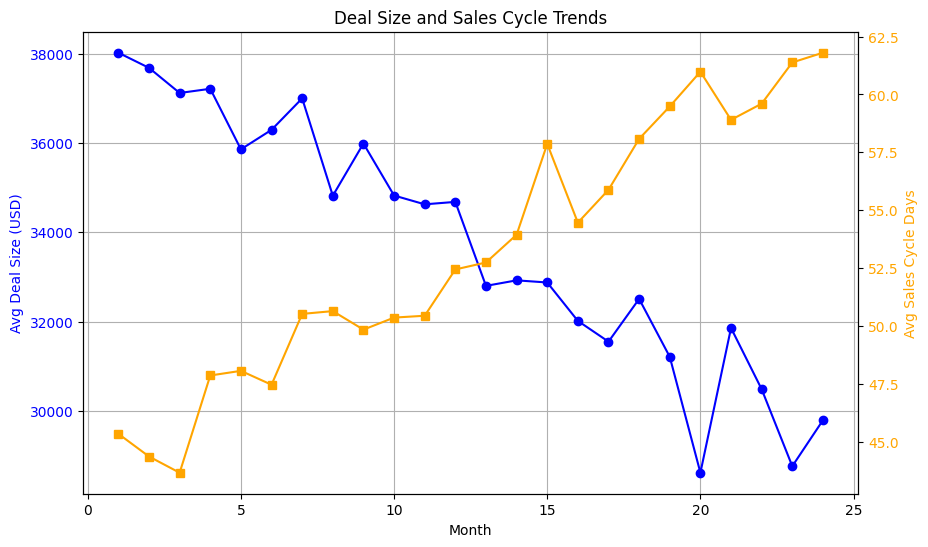

In [20]:
plt.figure(figsize=(10,6))

fig, ax1 = plt.subplots(figsize=(10,6))

# Primary axis (Deal Size)
ax1.plot(monthly_stats['Month'],
         monthly_stats['Deal_Size_Mean'],
         marker='o',
         color='blue',
         label='Avg Deal Size')

ax1.set_xlabel('Month')
ax1.set_ylabel('Avg Deal Size (USD)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary axis (Sales Cycle)
ax2 = ax1.twinx()

ax2.plot(monthly_stats['Month'],
         monthly_stats['Sales_Cycle_Mean'],
         marker='s',
         color='orange',
         label='Avg Sales Cycle Days')

ax2.set_ylabel('Avg Sales Cycle Days', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Title and grid
plt.title('Deal Size and Sales Cycle Trends')
ax1.grid(True)

plt.show()